In [1]:
%matplotlib inline
import math
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

np.set_printoptions(precision=6, suppress=True)
warnings.filterwarnings("ignore", message="A NumPy version")

# 使用系统中文字体，避免 matplotlib 图表中文标题显示为方框。
font_candidates = [
    r"C:\Windows\Fonts\msyh.ttc",
    r"C:\Windows\Fonts\simhei.ttf",
    r"C:\Windows\Fonts\NotoSansSC-VF.ttf",
]
for font_path in font_candidates:
    if __import__("pathlib").Path(font_path).exists():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams["font.sans-serif"] = [font_manager.FontProperties(fname=font_path).get_name()]
        break
plt.rcParams["axes.unicode_minus"] = False

## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知 
$$
a = [2,-1,3]^\top,\quad b = [1,4,-2]^\top
$$


矩阵

$$
A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix},\quad
B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}
$$

1. 内积：

    a · b =2×1+(-1)×4+3×(-2)=-8


2. 矩阵乘法：

    A 是 2×3，B 是 3×2，所以 AB 是 2×2。
    1×2+0×0+2×3=8

    1×1+0×(-1)+2×2=5

    -1×2+3×0+1×3=1

    -1×1+3×(-1)+1×2=-2

$$
AB=\begin{bmatrix}8&5\\1&-2\end{bmatrix}
$$

3. 向量 $a$ 的 Frobenius 范数：

$$
\|a\|_F = \sqrt{2^2+(-1)^2+3^2}=\sqrt{14}\approx 3.741657
$$

In [2]:
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

AB = A @ B
print("a · b =", a @ b)
print("A × B =\n", AB)
print("A × B 的形状 =", AB.shape)
print("||a||_F =", np.linalg.norm(a))

a · b = -8
A × B =
 [[ 8  5]
 [ 1 -2]]
A × B 的形状 = (2, 2)
||a||_F = 3.7416573867739413


### 2.2 编程题

In [3]:
# 1. 创建一个形状为 3 ×4 的随机矩阵 X，元素服从标准正态分布
rng = np.random.default_rng(2026)
X = rng.standard_normal((3, 4))

# 2. 创建一个形状为 4 ×2 的全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z= X×Y
Z = X @ Y

print("X =\n", X)
print("Y =\n", Y)
print("Z = X × Y =\n", Z)

# 4. 输出 Z的第一行和第二列交叉处的元素，以及 Z的第 2 行所有元素
print("Z 的第一行和第二列交叉处的元素 Z[0, 1] =", Z[0, 1])
print("Z 的第 2 行所有元素 =", Z[1, :])

# 5. 计算 Z的 Frobenius 范数
print("||Z||_F =", np.linalg.norm(Z, ord="fro"))

X =
 [[-0.793122  0.240571 -1.896326  1.395772]
 [ 0.638295 -0.292047 -0.311949  0.303835]
 [-0.26766  -0.225909  0.720068  0.514705]]
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = X × Y =
 [[-1.053106 -1.053106]
 [ 0.338133  0.338133]
 [ 0.741204  0.741204]]
Z 的第一行和第二列交叉处的元素 Z[0, 1] = -1.0531058311099954
Z 的第 2 行所有元素 = [0.338133 0.338133]
||Z||_F = 1.8829493793333987


## 3 概率

### 3.1 理论计算题

设患病率为 $P(D)=0.1\%=0.001$，检测真阳性率 $P(+\mid D)=99\%=0.99$，假阳性率 $P(+\mid \neg D)=2\%=0.02$。由贝叶斯公式：

$$
P(D\mid +)=\frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid \neg D)P(\neg D)}
$$

代入得：

$$
P(D\mid +)=\frac{0.99\times 0.001}{0.99\times 0.001+0.02\times 0.999}\approx 0.04721
$$

因此，检测为阳性时真正患病的概率约为 **4.72%**。

In [4]:
p_disease = 0.001
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.02

posterior = (p_pos_given_disease * p_disease) / (
    p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)
)
print(f"P(患病 | 阳性) = {posterior:.6f} = {posterior * 100:.2f}%")

P(患病 | 阳性) = 0.047210 = 4.72%


### 3.2 编程题


samples 的形状 = (1000, 10000)
sample_means 的形状 = (1000,)
1000 个样本均值的平均值 = 0.499952


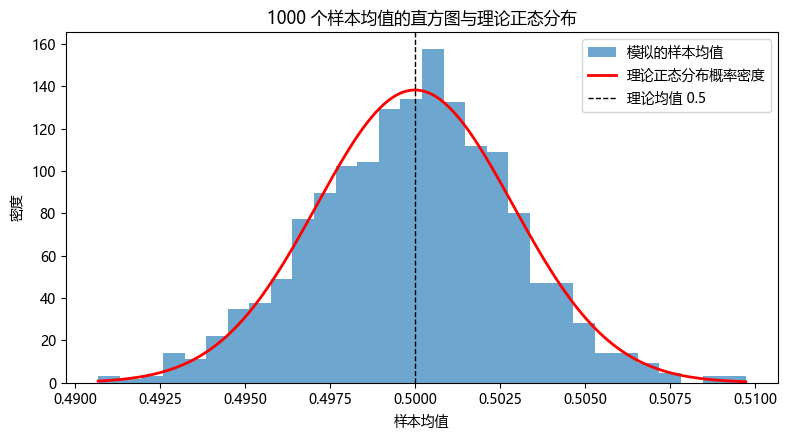

均值的实际方差 = 0.0000086140
理论方差 1/(12n) = 0.0000083333


In [5]:
# 第 1 步：生成 n=10000 个 U(0,1) 随机变量，重复 m=1000 次，并计算每次的均值。
rng_32 = np.random.default_rng(2026)
n = 10_000
m = 1_000

samples = rng_32.uniform(0, 1, size=(m, n))
sample_means = samples.mean(axis=1)

print("samples 的形状 =", samples.shape)
print("sample_means 的形状 =", sample_means.shape)
print(f"1000 个样本均值的平均值 = {sample_means.mean():.6f}")

# 第 2 步：绘制 1000 个均值的直方图，并叠加理论正态分布概率密度曲线。
theory_mean = 0.5
theory_variance = 1 / (12 * n)
theory_std = math.sqrt(theory_variance)

x_grid = np.linspace(sample_means.min(), sample_means.max(), 300)
normal_pdf = (
    1 / (theory_std * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x_grid - theory_mean) / theory_std) ** 2)
)

plt.figure(figsize=(8, 4.5))
plt.hist(sample_means, bins=30, density=True, alpha=0.65, label="模拟的样本均值")
plt.plot(x_grid, normal_pdf, "r", linewidth=2, label="理论正态分布概率密度")
plt.axvline(theory_mean, color="black", linestyle="--", linewidth=1, label="理论均值 0.5")
plt.xlabel("样本均值")
plt.ylabel("密度")
plt.title("1000 个样本均值的直方图与理论正态分布")
plt.legend()
plt.tight_layout()
plt.show()

# 第 3 步：计算这些均值的实际方差。
actual_variance = sample_means.var()

print(f"均值的实际方差 = {actual_variance:.10f}")
print(f"理论方差 1/(12n) = {theory_variance:.10f}")

## 4 求导

### 4.1 计算题

$$
z=(w_1x_1+w_2x_2-y)^2
$$

令

$$
e=w_1x_1+w_2x_2-y
$$

则 $z=e^2$，由链式法则：

$$
\frac{\partial z}{\partial w_1}=2e\cdot x_1=2(w_1x_1+w_2x_2-y)x_1
$$

$$
\frac{\partial z}{\partial w_2}=2e\cdot x_2=2(w_1x_1+w_2x_2-y)x_2
$$

代入 $x_1=2,x_2=1,y=3$：

$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3),\quad
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3)
$$

当 $w_1=0.5,w_2=1$ 时，$2w_1+w_2-3=-1$，因此：

$$
\frac{\partial z}{\partial w_1}=-4,\quad
\frac{\partial z}{\partial w_2}=-2
$$

In [6]:
x1, x2, y_true = 2.0, 1.0, 3.0
w1, w2 = 0.5, 1.0
error = w1 * x1 + w2 * x2 - y_true
z = error ** 2
dz_dw1 = 2 * error * x1
dz_dw2 = 2 * error * x2

print("z =", z)
print("∂z/∂w1 =", dz_dw1)
print("∂z/∂w2 =", dz_dw2)

z = 1.0
∂z/∂w1 = -4.0
∂z/∂w2 = -2.0


### 4.2 编程题

手动实现一个简单计算图的反向传播。前向计算为：

$$
a=x\cdot w_1,\quad b=a+w_2,\quad L=b^2
$$

给定 $x=2,w_1=1.5,w_2=0.5$。计算图中的局部导数为：

$$
\frac{\partial L}{\partial b}=2b,\quad
\frac{\partial b}{\partial a}=1,\quad
\frac{\partial b}{\partial w_2}=1,\quad
\frac{\partial a}{\partial w_1}=x
$$

按链式法则反向传播：

$$
\frac{\partial L}{\partial w_1}
=\frac{\partial L}{\partial b}\frac{\partial b}{\partial a}\frac{\partial a}{\partial w_1}
=2b\cdot x
$$

$$
\frac{\partial L}{\partial w_2}
=\frac{\partial L}{\partial b}\frac{\partial b}{\partial w_2}
=2b
$$

In [7]:
import torch

# 1. 前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向计算结果")
print("a =", a)
print("b =", b)
print("L =", L)

# 2. 手动按链式法则反向传播
dL_db = 2 * b
db_da = 1.0
db_dw2 = 1.0
da_dw1 = x

dL_da = dL_db * db_da
dL_dw1 = dL_da * da_dw1
dL_dw2 = dL_db * db_dw2

print("\n手动反向传播结果")
print("dL/db =", dL_db)
print("dL/da =", dL_da)
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

# 3. 使用 torch.autograd 验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

autograd_dw1 = float(w1_t.grad)
autograd_dw2 = float(w2_t.grad)

print("\ntorch.autograd 验证结果")
print("dL/dw1 =", autograd_dw1)
print("dL/dw2 =", autograd_dw2)
print("手动梯度与 autograd 是否一致 =", np.allclose([dL_dw1, dL_dw2], [autograd_dw1, autograd_dw2]))

前向计算结果
a = 3.0
b = 3.5
L = 12.25

手动反向传播结果
dL/db = 7.0
dL/da = 7.0
dL/dw1 = 14.0
dL/dw2 = 7.0

torch.autograd 验证结果
dL/dw1 = 14.0
dL/dw2 = 7.0
手动梯度与 autograd 是否一致 = True


## 5 线性方法、基础优化和 softmax 回归

### 5.1 理论计算题

模型为

$$
\hat y_i=wx_i+b
$$

均方误差损失为

$$
L=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2
$$

令 $e_i=\hat y_i-y_i=wx_i+b-y_i$，则

$$
L=\frac{1}{n}\sum_{i=1}^{n}e_i^2
$$

对 $w$ 和 $b$ 求导：

$$
\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

$$
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

### 5.2 编程题


epoch 10, loss = 0.4379, train acc = 0.9422
epoch 20, loss = 0.2922, train acc = 0.9499
epoch 30, loss = 0.2346, train acc = 0.9589
epoch 40, loss = 0.2020, train acc = 0.9638
epoch 50, loss = 0.1810, train acc = 0.9645
最终训练集准确率 = 0.9645
最终测试集准确率 = 0.9500


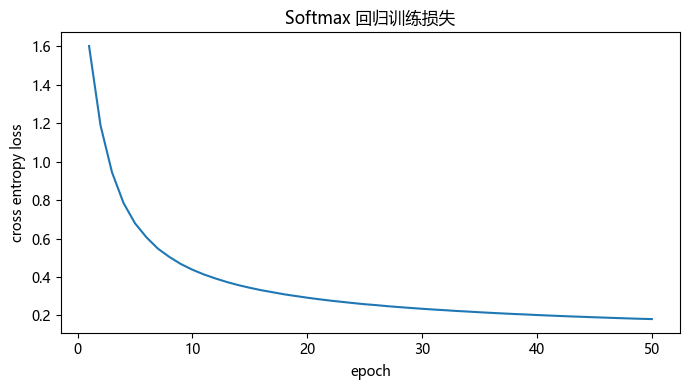

In [8]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


# 1. 使用 sklearn.datasets.load_digits() 加载手写数字数据，并把像素值归一化到 [0, 1]。
rng = np.random.default_rng(42)
digits = load_digits()
X_digits = digits.data.astype(np.float64) / 16.0
y_digits = digits.target.astype(int)
num_classes = 10


# 2. 划分训练集和测试集。
X_train, X_test, y_train, y_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.2,
    random_state=42,
    stratify=y_digits,
)


# 3. 实现 one-hot 编码、softmax 函数、交叉熵损失函数和准确率函数。
def one_hot(y, num_classes):
    encoded = np.zeros((len(y), num_classes))
    encoded[np.arange(len(y)), y] = 1.0
    return encoded


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum(axis=1, keepdims=True)


def cross_entropy(probs, labels_one_hot):
    eps = 1e-12
    return -np.mean(np.sum(labels_one_hot * np.log(probs + eps), axis=1))


def accuracy(X, y, W, b):
    preds = np.argmax(softmax(X @ W + b), axis=1)
    return np.mean(preds == y)


# 4. 初始化 softmax 回归模型参数。
Y_train = one_hot(y_train, num_classes)
num_features = X_train.shape[1]
W = rng.normal(0, 0.01, size=(num_features, num_classes))
b = np.zeros(num_classes)

learning_rate = 0.1
batch_size = 32
epochs = 50
loss_history = []


# 5. 使用小批量随机梯度下降训练模型：批量大小 32，学习率 0.1，训练 50 个 epoch。
for epoch in range(epochs):
    indices = rng.permutation(len(X_train))
    for start in range(0, len(X_train), batch_size):
        batch_idx = indices[start : start + batch_size]
        xb = X_train[batch_idx]
        yb = Y_train[batch_idx]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / len(batch_idx)
        grad_W = xb.T @ grad_logits
        grad_b = grad_logits.sum(axis=0)

        W -= learning_rate * grad_W
        b -= learning_rate * grad_b

    train_probs = softmax(X_train @ W + b)
    epoch_loss = cross_entropy(train_probs, Y_train)
    loss_history.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch + 1:02d}, loss = {epoch_loss:.4f}, train acc = {accuracy(X_train, y_train, W, b):.4f}")


# 6. 输出训练集和测试集准确率，并绘制训练损失曲线。
train_acc = accuracy(X_train, y_train, W, b)
test_acc = accuracy(X_test, y_test, W, b)
print(f"最终训练集准确率 = {train_acc:.4f}")
print(f"最终测试集准确率 = {test_acc:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, epochs + 1), loss_history)
plt.xlabel("epoch")
plt.ylabel("cross entropy loss")
plt.title("Softmax 回归训练损失")
plt.tight_layout()
plt.show()

## 6 最大似然估计和逻辑回归

### 6.1 计算题


1. 似然函数为：

$$
L(\mu,\sigma^2)=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

对应的对数似然为：

$$
\ell(\mu,\sigma^2)=-\frac{n}{2}\log(2\pi)-\frac{n}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

2. 证明：对 $\mu$ 求导：

$$
\frac{\partial \ell}{\partial \mu}=\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

令其等于 0：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
$$
$$
\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

3. 证明：令 $s=\sigma^2$，对 $s$ 求导：

$$
\frac{\partial \ell}{\partial s}=-\frac{n}{2s}+\frac{1}{2s^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

令其等于 0：

$$
-ns+\sum_{i=1}^{n}(x_i-\mu)^2=0
$$


$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$

### 6.2 编程题


iter 0200, loss = 0.0647, train acc = 0.9875
iter 0400, loss = 0.0501, train acc = 0.9875
iter 0600, loss = 0.0442, train acc = 0.9875
iter 0800, loss = 0.0409, train acc = 0.9875
iter 1000, loss = 0.0387, train acc = 0.9875
学习到的 w = [2.976083 2.128746]
学习到的 b = -0.027294695648725338
新生成测试集准确率 = 0.9750


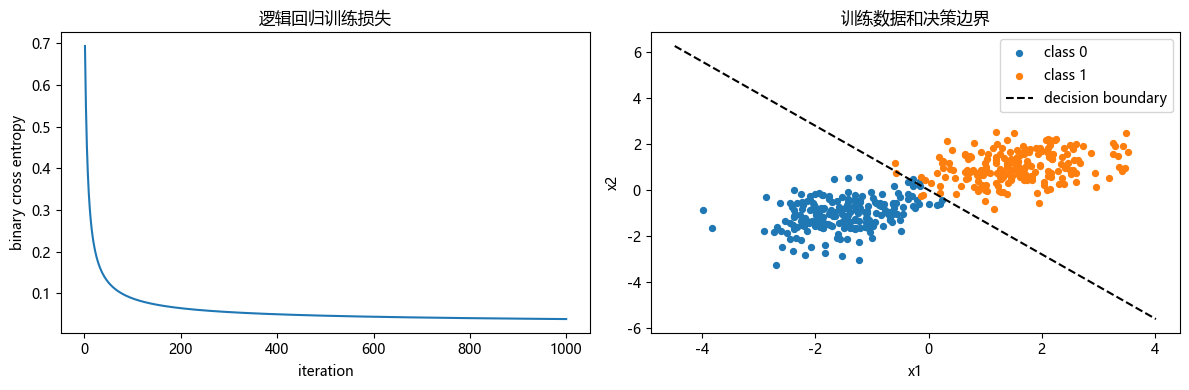

In [ ]:
rng = np.random.default_rng(42)


# 1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
def make_binary_data(n_per_class, rng):
    cov = np.array([[0.55, 0.15], [0.15, 0.55]])
    x0 = rng.multivariate_normal(mean=[-1.5, -1.0], cov=cov, size=n_per_class)
    x1 = rng.multivariate_normal(mean=[1.5, 1.0], cov=cov, size=n_per_class)
    X = np.vstack([x0, x1])
    y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])
    indices = rng.permutation(len(y))
    return X[indices], y[indices]


X_train_lr, y_train_lr = make_binary_data(200, rng)


# 2. 定义 sigmoid 函数和二元交叉熵损失。
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))


# 3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w,b。
w = np.zeros(X_train_lr.shape[1])
b = 0.0
learning_rate = 0.1
epochs = 1000
loss_history = []

for epoch in range(epochs):
    logits = X_train_lr @ w + b
    probs = sigmoid(logits)
    loss = binary_cross_entropy(y_train_lr, probs)
    loss_history.append(loss)

    error = probs - y_train_lr
    grad_w = X_train_lr.T @ error / len(y_train_lr)
    grad_b = np.mean(error)

    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if (epoch + 1) % 200 == 0:
        preds = (sigmoid(X_train_lr @ w + b) >= 0.5).astype(int)
        train_acc = np.mean(preds == y_train_lr)
        print(f"iter {epoch + 1:04d}, loss = {loss:.4f}, train acc = {train_acc:.4f}")


# 4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类准确率。
X_test_lr, y_test_lr = make_binary_data(100, rng)
test_probs = sigmoid(X_test_lr @ w + b)
test_preds = (test_probs >= 0.5).astype(int)
test_acc = np.mean(test_preds == y_test_lr)

print("学习到的 w =", w)
print("学习到的 b =", b)
print(f"新生成测试集准确率 = {test_acc:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.arange(1, epochs + 1), loss_history)
plt.xlabel("iteration")
plt.ylabel("binary cross entropy")
plt.title("逻辑回归训练损失")

plt.subplot(1, 2, 2)
plt.scatter(X_train_lr[y_train_lr == 0, 0], X_train_lr[y_train_lr == 0, 1], s=18, label="class 0")
plt.scatter(X_train_lr[y_train_lr == 1, 0], X_train_lr[y_train_lr == 1, 1], s=18, label="class 1")

x_min, x_max = X_train_lr[:, 0].min() - 0.5, X_train_lr[:, 0].max() + 0.5
x_line = np.linspace(x_min, x_max, 200)
if abs(w[1]) > 1e-12:
    y_line = -(w[0] * x_line + b) / w[1]
    plt.plot(x_line, y_line, "k--", label="decision boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("训练数据和决策边界")
plt.legend()
plt.tight_layout()
plt.show()